In [ ]:
using Pkg
Pkg.add(["XLSX", "DataFrames", "Statistics", "Plots", "StatsPlots"])

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Distances ───────── v0.10.12
   Installed CodecInflate64 ──── v0.1.3
   Installed ZipArchives ─────── v2.6.0
   Installed ArgCheck ────────── v2.5.0
   Installed StatsPlots ──────── v0.15.8
   Installed NearestNeighbors ── v0.4.27
   Installed Clustering ──────── v0.15.8
   Installed Widgets ─────────── v0.6.7
   Installed Arpack ──────────── v0.5.4
   Installed XML ─────────────── v0.3.8
   Installed InputBuffers ────── v1.1.1
   Installed TableOperations ─── v1.2.0
   Installed Arpack_jll ──────── v3.5.2+0
   Installed MultivariateStats ─ v0.10.4
   Installed XLSX ────────────── v0.11.4
  Installing 1 artifacts
   Installed artifact Arpack                   138.3 KiB
    Updating `~/.julia/environments/v1.12/Project.toml`
  [10745b16] + Statistics v1.11.1
  [f3b207a7] + StatsPlots v0.15.8
  [fdbf4ff8] + XLSX v0.11.4
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [dce0

In [ ]:
using XLSX
using DataFrames
using Statistics
using Plots
using StatsPlots
using Printf

In [ ]:
# --- 1. CARGA DE DATOS DESDE EXCEL ---
file_path = "ComercioInternacional.xlsx"

"ComercioInternacional.xlsx"

In [ ]:
# 2. Carga de datos
xf = XLSX.readxlsx(file_path)
nombre_hoja = XLSX.sheetnames(xf)[1]

# Cargamos la tabla completa
data_table = XLSX.readtable(file_path, nombre_hoja; infer_eltypes=true)
df = DataFrame(data_table)

Row,Rkn,Partida,Descripcion,Pais,Año,Mes,Peso Neto(t),Peso Bruto (t),Valor FOB (t)
,Int64,String,String,String,Int64,String,Float64,Float64,Float64
1,2,0806100000,UVAS FRESCAS,ESTADOS UNIDOS,2026,01,1.13181e5,1.31779e5,3.05023e5
2,3,0810400000,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",ESTADOS UNIDOS,2026,01,17223.0,21028.6,1.08954e5
3,4,0804502000,"MANGOS Y MANGOSTANES, FRESCOS O SECOS",ESTADOS UNIDOS,2026,01,33940.8,37758.7,50532.2
4,5,0806100000,UVAS FRESCAS,MEXICO,2026,01,15595.3,18070.5,48686.8
5,6,0806100000,UVAS FRESCAS,HOLANDA,2026,01,12175.5,14272.0,34111.7
6,7,0810400000,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",HOLANDA,2026,01,5314.76,6548.04,33164.5
7,8,0804502000,"MANGOS Y MANGOSTANES, FRESCOS O SECOS",HOLANDA,2026,01,22113.4,24776.4,29816.7
8,9,0806100000,UVAS FRESCAS,TAIWAN (FORMOSA),2026,01,4068.86,4752.39,17303.5
9,10,0806100000,UVAS FRESCAS,ESPAÑA,2026,01,6185.42,7147.73,16553.1


In [ ]:
# 3. Mostrar todas las columnas del archivo (Punto 2 solicitado)
println("\n--- TODAS LAS COLUMNAS DETECTADAS ---")
println(names(df))
println("-"^40)


--- TODAS LAS COLUMNAS DETECTADAS ---
["Rkn", "Partida", "Descripcion", "Pais", "Año", "Mes", "Peso Neto(t)", "Peso Bruto (t)", "Valor FOB (t)"]
----------------------------------------


In [ ]:
# 4. ANÁLISIS EXPLORATORIO (Columnas Numéricas)
columnas_nombres = names(df)[[7, 8, 9]]
df_numerico = df[:, columnas_objetivo]
nombres_num = names(df_numerico)

println("\n--- ANÁLISIS EXPLORATORIO (Columnas Numéricas) ---")
display(describe(df_numerico, :mean, :min, :max, :std, :median))


--- ANÁLISIS EXPLORATORIO (Columnas Numéricas) ---


Row,variable,mean,min,max,std,median
,Symbol,Float64,Float64,Float64,Float64,Float64
1,Peso Neto(t),966.155,0.0,1.13181e5,6758.89,37.39
2,Peso Bruto (t),1109.29,0.0,1.31779e5,7841.81,44.84
3,Valor FOB (t),2583.91,0.0,3.05023e5,18453.1,97.92


In [ ]:
# ---  LIMPIEZA Y PREPARACIÓN PARA GRÁFICOS ---
# Filtramos valores mayores a 0 para evitar errores en escala logarítmica
df_plot = filter(row -> row[nombres_num[3]] > 0, df)

Row,Rkn,Partida,Descripcion,Pais,Año,Mes,Peso Neto(t),Peso Bruto (t),Valor FOB (t)
,Int64,String,String,String,Int64,String,Float64,Float64,Float64
1,2,0806100000,UVAS FRESCAS,ESTADOS UNIDOS,2026,01,1.13181e5,1.31779e5,3.05023e5
2,3,0810400000,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",ESTADOS UNIDOS,2026,01,17223.0,21028.6,1.08954e5
3,4,0804502000,"MANGOS Y MANGOSTANES, FRESCOS O SECOS",ESTADOS UNIDOS,2026,01,33940.8,37758.7,50532.2
4,5,0806100000,UVAS FRESCAS,MEXICO,2026,01,15595.3,18070.5,48686.8
5,6,0806100000,UVAS FRESCAS,HOLANDA,2026,01,12175.5,14272.0,34111.7
6,7,0810400000,"ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS",HOLANDA,2026,01,5314.76,6548.04,33164.5
7,8,0804502000,"MANGOS Y MANGOSTANES, FRESCOS O SECOS",HOLANDA,2026,01,22113.4,24776.4,29816.7
8,9,0806100000,UVAS FRESCAS,TAIWAN (FORMOSA),2026,01,4068.86,4752.39,17303.5
9,10,0806100000,UVAS FRESCAS,ESPAÑA,2026,01,6185.42,7147.73,16553.1


In [ ]:
gr(size=(800, 1000)) #font

# Calculamos el límite para el zoom (Percentil 95)
limite_fob = quantile(df_plot[!, nombres_num[3]], 0.95)

4840.743499999996

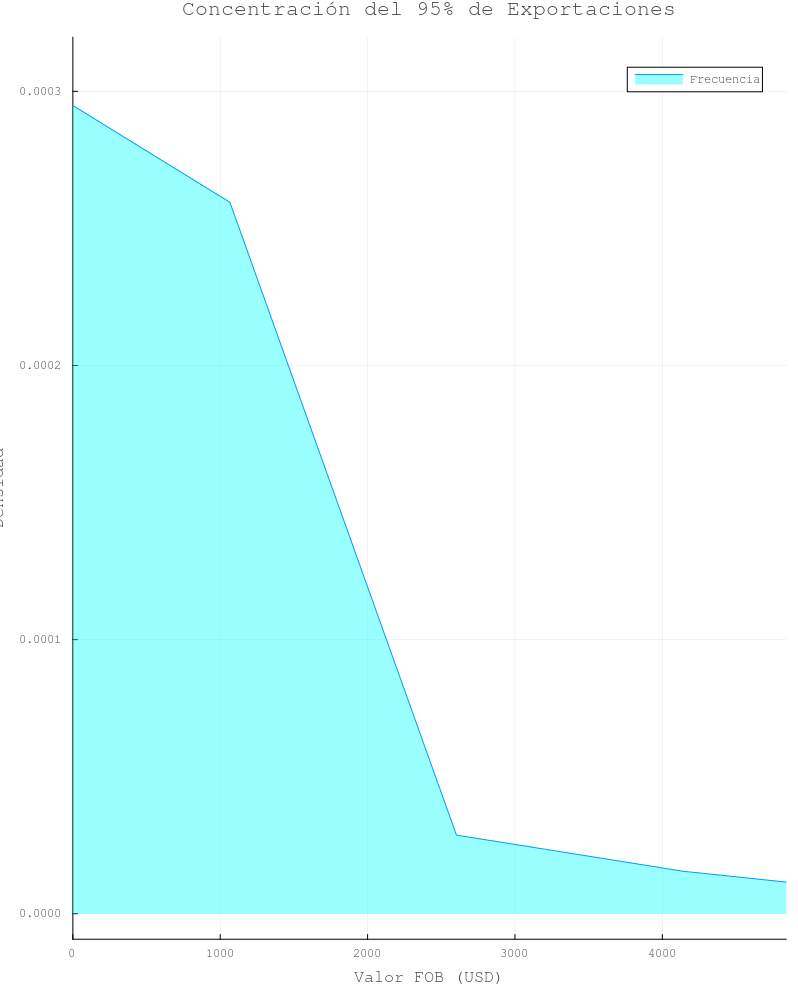

In [ ]:
# --- GRÁFICO 1: DENSIDAD CON ZOOM ---
p1 = density(df_plot[!, nombres_num[3]],
fill=(0, .4, :cyan), xlims=(0, limite_fob),
title="Concentración del 95% de Exportaciones",
xlabel="Valor FOB (USD)", ylabel="Densidad", label="Frecuencia")

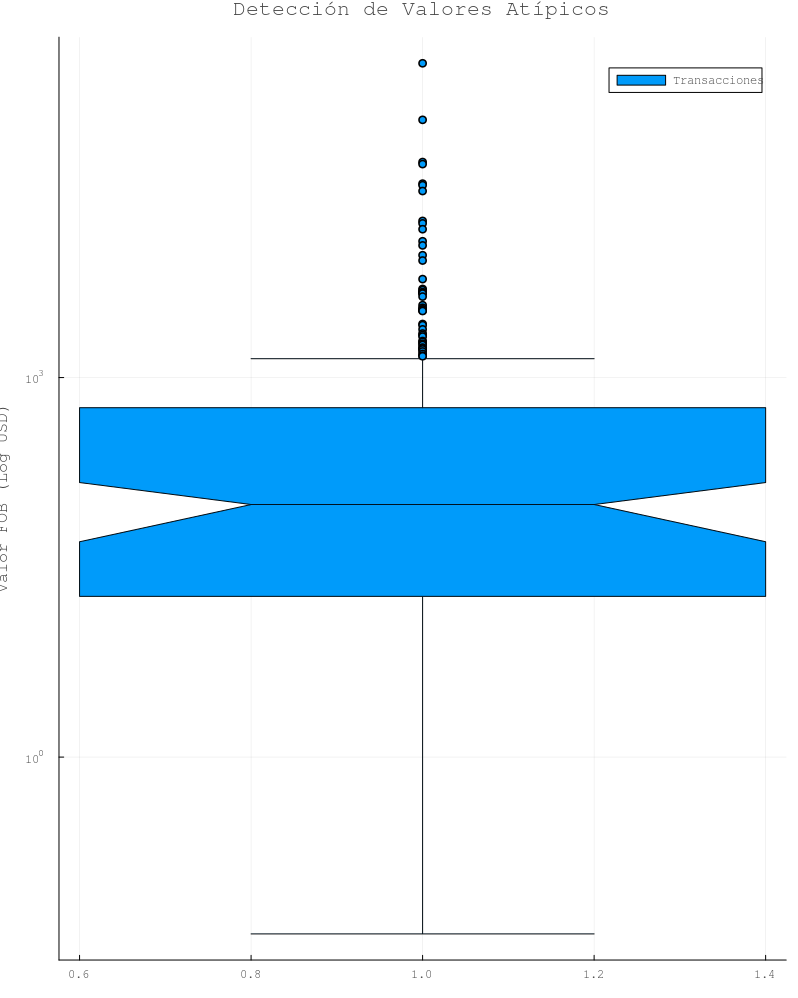

In [ ]:
# --- GRÁFICO 2: BOXPLOT (ESCALA LOG) ---
# Usamos log aquí para que la 'caja' sea visible junto a los puntos altos
p2 = boxplot(df_plot[!, nombres_num[3]],
yscale=:log10, title="Detección de Valores Atípicos",
ylabel="Valor FOB (Log USD)", label="Transacciones", notch=true)

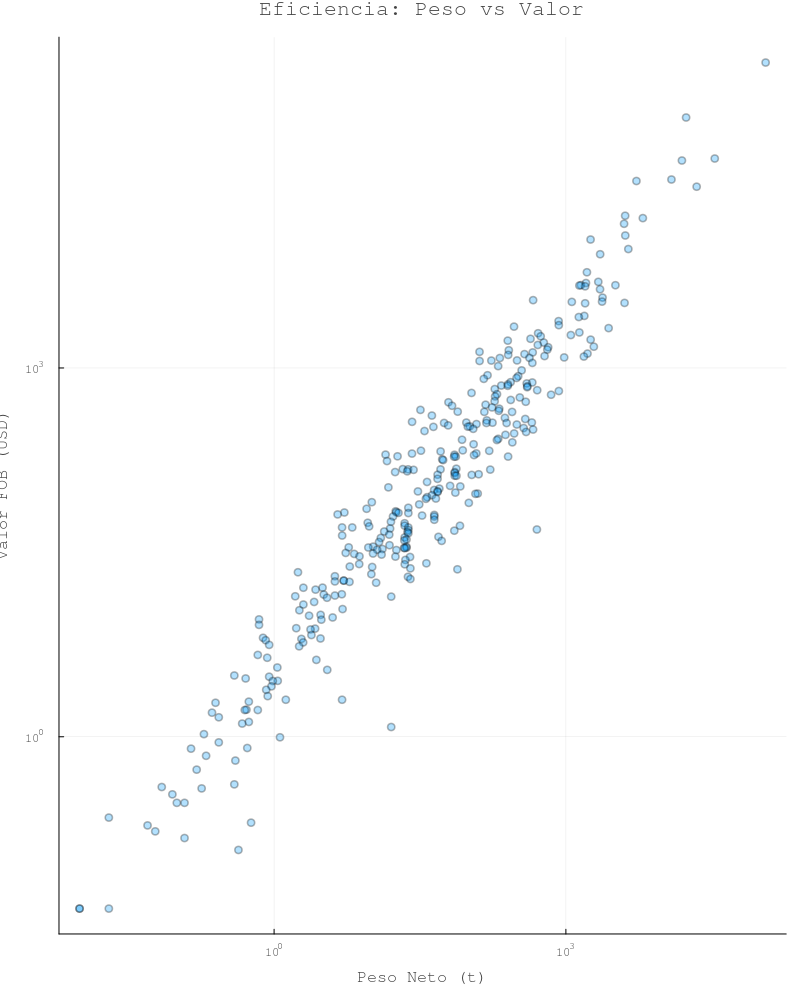

In [ ]:
# --- GRÁFICO 3: RELACIÓN PESO/VALOR (SCATTER) ---
p3 = scatter(df_plot[!, nombres_num[1]], df_plot[!, nombres_num[3]],
xscale=:log10, yscale=:log10, alpha=0.3,
title="Eficiencia: Peso vs Valor",
xlabel="Peso Neto (t)", ylabel="Valor FOB (USD)", label="")


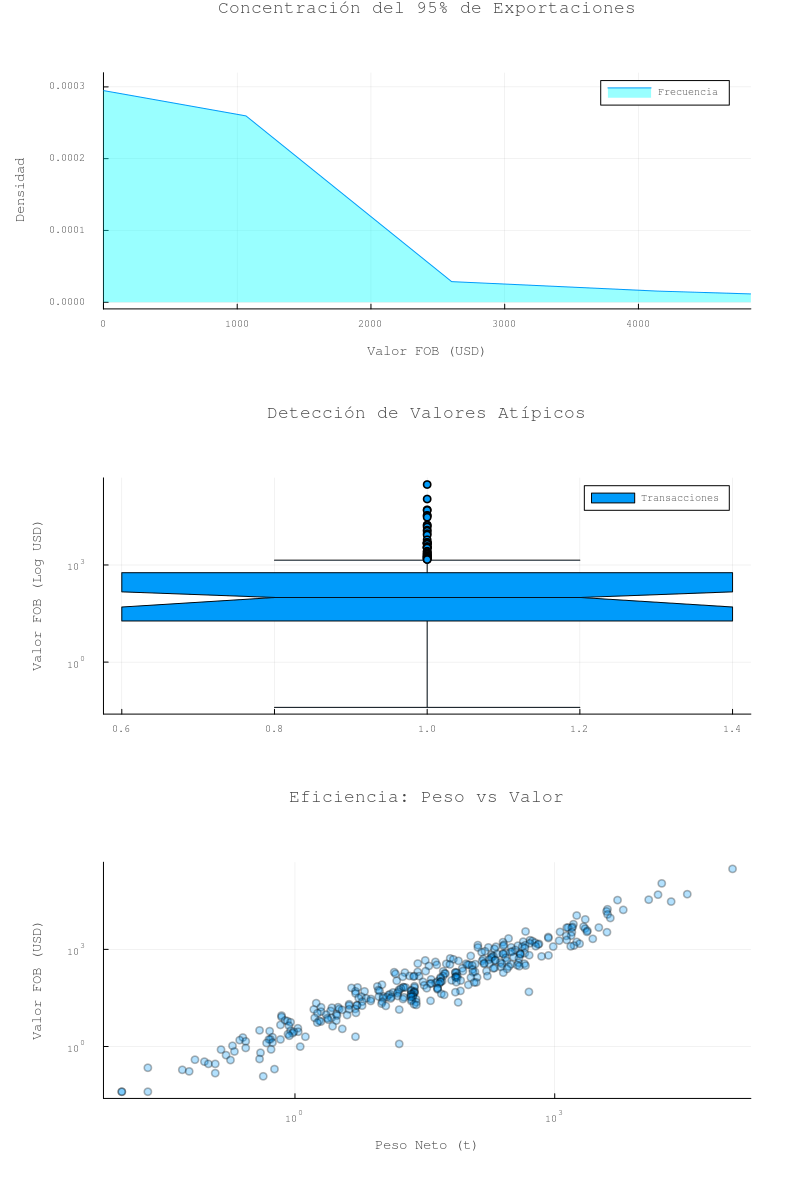

In [ ]:
# Mostrar layout
display(plot(p1, p2, p3, layout=(3,1), size=(800,1200), margin=10Plots.mm))